# ROC-Kurve – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/roc-kurve)

Die **ROC-Kurve** (Receiver Operating Characteristic) zeigt die Leistung eines
binären Klassifikationsmodells über **alle möglichen Schwellenwerte**.

**Kernbegriffe:**

| Begriff | Formel | Bedeutung |
|---|---|---|
| **TPR** (Sensitivität) | TP / (TP + FN) | Anteil Kranke korrekt als krank erkannt |
| **FPR** (1 - Spezifität) | FP / (FP + TN) | Anteil Gesunde fälschlich als krank klassifiziert |
| **AUC** | Fläche unter ROC-Kurve | Gesamtgüte des Modells (0,5–1,0) |

**Konfusionsmatrix:**

| | Pred: positiv | Pred: negativ |
|---|---|---|
| **True: positiv** | TP (richtig krank) | FN (falsch gesund) |
| **True: negativ** | FP (falsch krank) | TN (richtig gesund) |

**AUC-Interpretation:**

| AUC | Qualität |
|---|---|
| 1,0 | Perfekter Klassifizierer |
| 0,9 – 1,0 | Ausgezeichnet |
| 0,8 – 0,9 | Gut |
| 0,7 – 0,8 | Akzeptabel |
| 0,5 – 0,7 | Schwach |
| 0,5 | Zufallsklassifizierer (Diagonale) |

In [3]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
import statsmodels.formula.api as smf
from sklearn.metrics import roc_curve, auc, confusion_matrix

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Krebsdiagnose per Blutwert (n=10)

**Datensatz:** 10 Personen, 5 krank (1), 5 gesund (0)

| Person | Blutwert | Erkrankt |
|---|---|---|
| 1 | 30 | 0 |
| 2 | 35 | 0 |
| 3 | 40 | 0 |
| 4 | 43 | 1 |
| 5 | 45 | 0 |
| 6 | 47 | 1 |
| 7 | 50 | 0 |
| 8 | 55 | 1 |
| 9 | 60 | 1 |
| 10 | 65 | 1 |

**Schwellenwert 45:** TPR = 4/5 = 0,8, FPR = 2/5 = 0,4 (numiqo)

In [5]:
# numiqo-Datensatz
blutwert  = np.array([30, 35, 40, 43, 45, 47, 50, 55, 60, 65], dtype=float)
erkrankt  = np.array([0,  0,  0,  1,  0,  1,  0,  1,  1,  1], dtype=int)
n = len(blutwert)
n_pos = erkrankt.sum()
n_neg = n - n_pos

print("numiqo-Datensatz: Krebsdiagnose")
print("n=" + str(n) + "  Krank=" + str(n_pos) + "  Gesund=" + str(n_neg))
print()

# Schwellenwert 45 (numiqo-Beispiel)
schwelle = 45
pred_45 = (blutwert >= schwelle).astype(int)
TP = ((pred_45 == 1) & (erkrankt == 1)).sum()
FN = ((pred_45 == 0) & (erkrankt == 1)).sum()
FP = ((pred_45 == 1) & (erkrankt == 0)).sum()
TN = ((pred_45 == 0) & (erkrankt == 0)).sum()

TPR = TP / (TP + FN)
FPR = FP / (FP + TN)

print("Schwellenwert = 45")
print("TP=" + str(TP) + "  FN=" + str(FN) + "  FP=" + str(FP) + "  TN=" + str(TN))
print("TPR (Sensitiviät) = " + str(TP) + "/" + str(TP+FN) +
      " = " + str(round(TPR, 2)) + "  (numiqo: 0.8)")
print("FPR (1-Spezif.)     = " + str(FP) + "/" + str(FP+TN) +
      " = " + str(round(FPR, 2)) + "  (numiqo: 0.4)")
print()

# Alle Schwellenwerte durchlaufen
print("ROC-Punkte für alle Schwellenwerte")
print("Schwelle  TP  FN  FP  TN   TPR    FPR")
schwellen = sorted(set(blutwert)) + [max(blutwert)+1]
roc_pts = []
for sw in schwellen:
    pred = (blutwert >= sw).astype(int)
    tp_s = ((pred==1) & (erkrankt==1)).sum()
    fn_s = ((pred==0) & (erkrankt==1)).sum()
    fp_s = ((pred==1) & (erkrankt==0)).sum()
    tn_s = ((pred==0) & (erkrankt==0)).sum()
    tpr_s = tp_s / (tp_s + fn_s) if (tp_s+fn_s) > 0 else 0
    fpr_s = fp_s / (fp_s + tn_s) if (fp_s+tn_s) > 0 else 0
    roc_pts.append((sw, tp_s, fn_s, fp_s, tn_s, tpr_s, fpr_s))
    print(str(int(sw)) + "        " + str(tp_s) + "   " + str(fn_s) +
          "   " + str(fp_s) + "   " + str(tn_s) +
          "   " + str(round(tpr_s,2)) + "   " + str(round(fpr_s,2)))

fpr_arr = np.array([p[6] for p in roc_pts])
tpr_arr = np.array([p[5] for p in roc_pts])
auc_man = np.trapezoid(tpr_arr[::-1], fpr_arr[::-1])
print()
print("AUC (manuell) = " + str(round(auc_man, 4)))

numiqo-Datensatz: Krebsdiagnose
n=10  Krank=5  Gesund=5

Schwellenwert = 45
TP=4  FN=1  FP=2  TN=3
TPR (Sensitiviät) = 4/5 = 0.8  (numiqo: 0.8)
FPR (1-Spezif.)     = 2/5 = 0.4  (numiqo: 0.4)

ROC-Punkte für alle Schwellenwerte
Schwelle  TP  FN  FP  TN   TPR    FPR
30        5   0   5   0   1.0   1.0
35        5   0   4   1   1.0   0.8
40        5   0   3   2   1.0   0.6
43        5   0   2   3   1.0   0.4
45        4   1   2   3   0.8   0.4
47        4   1   1   4   0.8   0.2
50        3   2   1   4   0.6   0.2
55        3   2   0   5   0.6   0.0
60        2   3   0   5   0.4   0.0
65        1   4   0   5   0.2   0.0
66        0   5   0   5   0.0   0.0

AUC (manuell) = 0.88


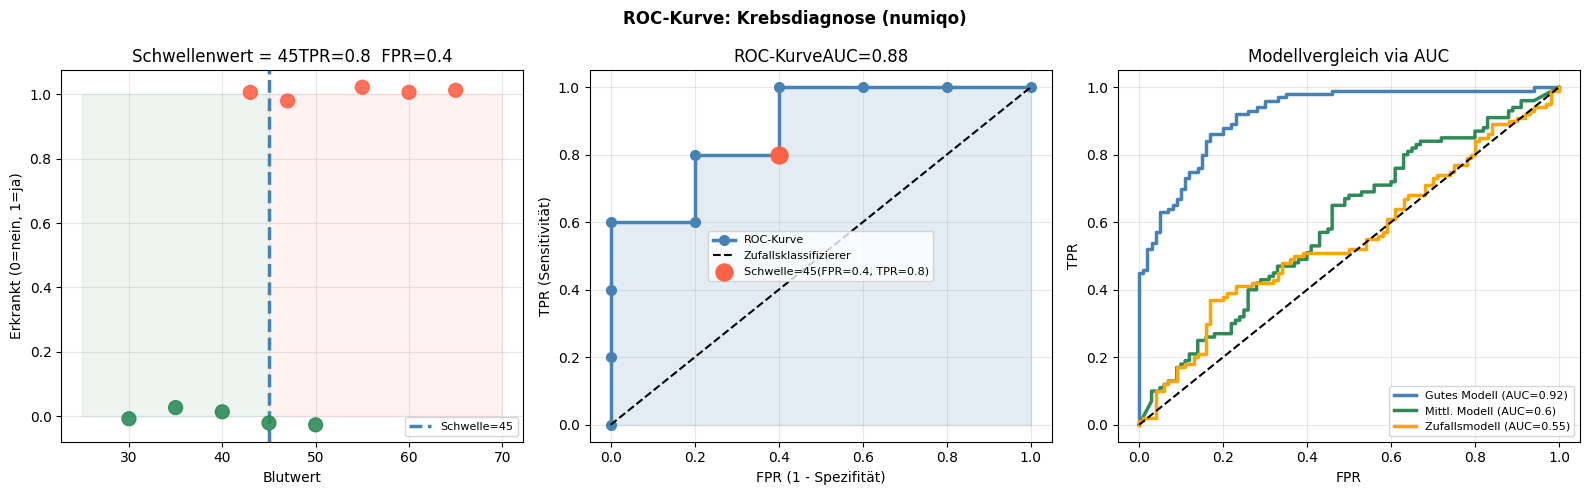

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("ROC-Kurve: Krebsdiagnose (numiqo)", fontsize=12, fontweight="bold")

# 1. Schwellenwert-Illustration
farben_pt = {0: "seagreen", 1: "tomato"}
fc_pts = [farben_pt[e] for e in erkrankt]
axes[0].scatter(blutwert, erkrankt + np.random.uniform(-0.03, 0.03, n),
                c=fc_pts, s=100, alpha=0.9, zorder=3)
axes[0].axvline(45, color="steelblue", linewidth=2.5, linestyle="--",
                label="Schwelle=45")
axes[0].fill_betweenx([0, 1], 45, 70, alpha=0.08, color="tomato")
axes[0].fill_betweenx([0, 1], 25, 45, alpha=0.08, color="seagreen")
axes[0].set_title("Schwellenwert = 45TPR=0.8  FPR=0.4")
axes[0].set_xlabel("Blutwert")
axes[0].set_ylabel("Erkrankt (0=nein, 1=ja)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 2. ROC-Kurve (numiqo-Beispiel)
axes[1].plot(fpr_arr[::-1], tpr_arr[::-1], "o-", color="steelblue",
             linewidth=2.5, markersize=7, label="ROC-Kurve")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Zufallsklassifizierer")
axes[1].fill_between(fpr_arr[::-1], tpr_arr[::-1], alpha=0.15, color="steelblue")
# Punkt für Schwelle 45
axes[1].scatter([FPR], [TPR], color="tomato", s=150, zorder=5,
                label="Schwelle=45(FPR=" + str(round(FPR,2)) + ", TPR=" + str(round(TPR,2)) + ")")
axes[1].set_title("ROC-KurveAUC=" + str(round(auc_man, 3)))
axes[1].set_xlabel("FPR (1 - Spezifität)")
axes[1].set_ylabel("TPR (Sensitivität)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)

# 3. Verschiedene Modelle vergleichen
np.random.seed(42)
n_comp = 200
y_true = np.random.choice([0, 1], n_comp)
# Gutes Modell
scores_gut  = y_true * np.random.normal(0.7, 0.2, n_comp) + (1-y_true) * np.random.normal(0.3, 0.2, n_comp)
scores_gut  = np.clip(scores_gut, 0, 1)
# Mittleres Modell
scores_mittel = y_true * np.random.normal(0.6, 0.3, n_comp) + (1-y_true) * np.random.normal(0.4, 0.3, n_comp)
scores_mittel = np.clip(scores_mittel, 0, 1)
# Zufallsmodell
scores_zufall = np.random.uniform(0, 1, n_comp)

for scores, name, fc in [
    (scores_gut,    "Gutes Modell",    "steelblue"),
    (scores_mittel, "Mittl. Modell",   "seagreen"),
    (scores_zufall, "Zufallsmodell",   "orange"),
]:
    fpr_c, tpr_c, _ = roc_curve(y_true, scores)
    auc_c = auc(fpr_c, tpr_c)
    axes[2].plot(fpr_c, tpr_c, linewidth=2.5, color=fc,
                 label=name + " (AUC=" + str(round(auc_c, 2)) + ")")

axes[2].plot([0, 1], [0, 1], "k--", linewidth=1.5)
axes[2].set_title("Modellvergleich via AUC")
axes[2].set_xlabel("FPR")
axes[2].set_ylabel("TPR")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. ROC-Kurve + Logistische Regression

Bei der logistischen Regression liefert `model.predict()` Wahrscheinlichkeiten
zwischen 0 und 1. Die ROC-Kurve zeigt, wie gut das Modell über alle Schwellen
trennt – unabhängig von der gewählten 0,5-Grenze.

ROC + Logistische Regression
Modell 1 (nur Blutwert):    AUC=0.8012
Modell 2 (Blutwert + Alter): AUC=0.8745

Modell 2 ist besser -> Alter verbessert die Klassifikation

Optimaler Schwellenwert (Youden-Index):
  Schwelle = 0.3033
  TPR      = 0.7609
  FPR      = 0.1494


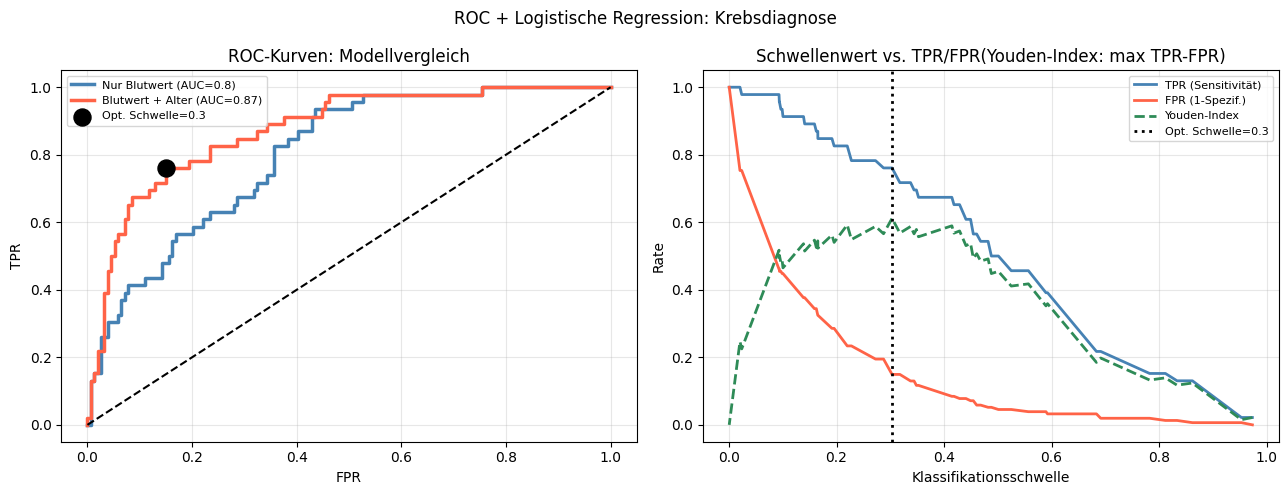

In [7]:
# Logistische Regression + ROC-Kurve
np.random.seed(42)
n_lr = 200
alter_lr = np.random.normal(45, 15, n_lr).clip(20, 80)
blutwert_lr = np.random.normal(50, 15, n_lr).clip(10, 90)
logit_lr = -8 + 0.05*alter_lr + 0.08*blutwert_lr
erkrankt_lr = (np.random.uniform(0,1,n_lr) < expit(logit_lr)).astype(int)

df_lr = pd.DataFrame({"erkrankt": erkrankt_lr, "alter": alter_lr,
                       "blutwert": blutwert_lr})

# Modell 1: nur Blutwert
m1 = smf.logit("erkrankt ~ blutwert", data=df_lr).fit(disp=0)
# Modell 2: Blutwert + Alter
m2 = smf.logit("erkrankt ~ blutwert + alter", data=df_lr).fit(disp=0)

pred1 = m1.predict(df_lr)
pred2 = m2.predict(df_lr)

fpr1, tpr1, thr1 = roc_curve(erkrankt_lr, pred1)
fpr2, tpr2, thr2 = roc_curve(erkrankt_lr, pred2)
auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)

print("ROC + Logistische Regression")
print("Modell 1 (nur Blutwert):    AUC=" + str(round(auc1, 4)))
print("Modell 2 (Blutwert + Alter): AUC=" + str(round(auc2, 4)))
print()
print("Modell 2 ist besser -> Alter verbessert die Klassifikation")
print()

# Optimaler Schwellenwert (Youden-Index: max(TPR - FPR))
youden = tpr2 - fpr2
opt_idx = np.argmax(youden)
opt_thr = thr2[opt_idx]
print("Optimaler Schwellenwert (Youden-Index):")
print("  Schwelle = " + str(round(opt_thr, 4)))
print("  TPR      = " + str(round(tpr2[opt_idx], 4)))
print("  FPR      = " + str(round(fpr2[opt_idx], 4)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ROC + Logistische Regression: Krebsdiagnose", fontsize=12)

axes[0].plot(fpr1, tpr1, color="steelblue", linewidth=2.5,
             label="Nur Blutwert (AUC=" + str(round(auc1,2)) + ")")
axes[0].plot(fpr2, tpr2, color="tomato", linewidth=2.5,
             label="Blutwert + Alter (AUC=" + str(round(auc2,2)) + ")")
axes[0].scatter([fpr2[opt_idx]], [tpr2[opt_idx]], color="black", s=150, zorder=5,
                label="Opt. Schwelle=" + str(round(opt_thr,2)))
axes[0].plot([0,1],[0,1],"k--",linewidth=1.5)
axes[0].set_title("ROC-Kurven: Modellvergleich")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Schwellenwert vs. TPR/FPR
thresholds_plot = thr2[1:]
axes[1].plot(thresholds_plot, tpr2[1:], color="steelblue", linewidth=2,
             label="TPR (Sensitivität)")
axes[1].plot(thresholds_plot, fpr2[1:], color="tomato", linewidth=2,
             label="FPR (1-Spezif.)")
axes[1].plot(thresholds_plot, tpr2[1:]-fpr2[1:], color="seagreen",
             linewidth=2, linestyle="--", label="Youden-Index")
axes[1].axvline(opt_thr, color="black", linestyle=":", linewidth=2,
                label="Opt. Schwelle=" + str(round(opt_thr,2)))
axes[1].set_title("Schwellenwert vs. TPR/FPR(Youden-Index: max TPR-FPR)")
axes[1].set_xlabel("Klassifikationsschwelle")
axes[1].set_ylabel("Rate")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Zusammenfassung

```
ROC-Kurve – Übersicht
│
├── WAS?
│   Grafische Darstellung der Klassifikationsgüte
│   über alle möglichen Schwellenwerte
│   x-Achse: FPR (1 - Spezifität)
│   y-Achse: TPR (Sensitivität)
│
├── KONFUSIONSMATRIX
│   TP: krank richtig als krank erkannt
│   TN: gesund richtig als gesund erkannt
│   FP: gesund fälschlich als krank (Alarm)
│   FN: krank fälschlich als gesund (Miss)
│
├── KENNZAHLEN
│   TPR = TP / (TP + FN)  (Sensitivität)
│   FPR = FP / (FP + TN)  (1 - Spezifität)
│   AUC = Fläche unter der ROC-Kurve
│
├── AUC-INTERPRETATION
│   1.0:       perfekt
│   0.9 - 1.0: ausgezeichnet
│   0.8 - 0.9: gut
│   0.7 - 0.8: akzeptabel
│   0.5 - 0.7: schwach
│   0.5:       Zufallsklassifizierer (Diagonale)
│
├── OPTIMALER SCHWELLENWERT
│   Youden-Index: max(TPR - FPR)
│   Oder je nach Anwendung: hohe Sensitivität
│   (z.B. Krebs: lieber FP als FN!)
│
├── numiqo-BEISPIEL: Krebsdiagnose (n=10)
│   Schwellenwert 45: TPR=0.8, FPR=0.4
│   ROC-Kurve zeigt alle Schwellenwerte
│
└── PYTHON
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc_wert = auc(fpr, tpr)
```

---
Quelle: [numiqo.de/tutorial/roc-kurve](https://numiqo.de/tutorial/roc-kurve)